<a href="https://colab.research.google.com/github/nicolastibata/MINE_4210_ADL_202620/blob/main/labs/Laboratorio_4/MINE_4210_ADL_202620_L4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo ADL](https://github.com/nicolastibata/MINE_4210_ADL_202620/blob/main/docs/logo.png?raw=true)


# **Laboratorio 4: Modelo preentrenado para clasificación de imágenes**
**Tutor: Nicolás Tibatá**

## **Tabla de Contenido**

[Contexto y objetivos](#scrollTo=R4YrUaE6udsU&line=14&uniqifier=1)<br>
[1. Comprensión de los datos](#scrollTo=VjA8zwzJvmeO&line=1&uniqifier=1)<br>
[2. Preparación de los datos](#scrollTo=kG8XHROzvuEH&line=1&uniqifier=1)<br>
[3. Modelamiento](#scrollTo=wCS6xYiU4YYs&line=1&uniqifier=1)<br>
[4. Evaluación](#scrollTo=nnCc67Uf5urd&line=1&uniqifier=1)<br>
[5. Preguntas](#scrollTo=HnWtjBcSv3yG&line=1&uniqifier=1)<br>


### **Contexto y Objetivos**

**Problema**
- La acumulación masiva de residuos sólidos y la falta de una gestión eficiente son desafíos ambientales críticos a nivel global. Un punto fundamental en el proceso de reciclaje es la clasificación de la basura y realizar este proceso manual termina siendo muy costoso y lento. Por eso queremos usar un modelo preentrenado robusto como lo es `ResNet50V2` + una capa de clasificación para poder segmentar correctamente y poder optimizar estos procesos.

**Objetivos**
1. Implementar un modelo preentrenado para la clasificación de imágenes.
2. Entender la arquitectura ResNet + Transfer Learning.

**Datos**

Los datos los puedes consultar [aquí](https://www.kaggle.com/datasets/butleriii/garbage-dataset-from-various-sources).

In [ ]:
# Librerias que necesitamos para este lab
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import userdata

import tensorflow as tf
from tensorflow import keras
from keras.utils import plot_model
from keras.applications import ResNet50V2
from keras.applications.resnet_v2 import preprocess_input
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling2D, Dropout
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

### **1. Comprensión de los datos**

El dataset contiene 20194 imágenes de diferentes clases como son: Battery, Cardboard, Glass, Metal, Paper, Plastic, Trash. Las cuales son nuestras clases a clasificar.

Son imágenes de 128x128 a color, ubicados en el folder `Garbage classification`.


Para entender cómo traemos los datos desde kaggle pueden revisar este [link](https://www.kaggle.com/discussions/general/51898#520673)

In [ ]:
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

!kaggle datasets download -d butleriii/garbage-dataset-from-various-sources

! unzip "garbage-dataset-from-various-sources.zip"

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: Garbage classification/plastic/0224012249.jpg  
  inflating: Garbage classification/plastic/0224012301.jpg  
  inflating: Garbage classification/plastic/0224012318.jpg  
  inflating: Garbage classification/plastic/0224012332.jpg  
  inflating: Garbage classification/plastic/0224012615.jpg  
  inflating: Garbage classification/plastic/0224012632.jpg  
  inflating: Garbage classification/plastic/0224012656.jpg  
  inflating: Garbage classification/plastic/0224012745.jpg  
  inflating: Garbage classification/plastic/0224012817.jpg  
  inflating: Garbage classification/plastic/0224012844.jpg  
  inflating: Garbage classification/plastic/0224012945.jpg  
  inflating: Garbage classification/plastic/0224013000.jpg  
  inflating: Garbage classification/plastic/0224013019.jpg  
  inflating: Garbage classification/plastic/0224013102.jpg  
  inflating: Garbage classification/plastic/0224013124.jpg  
  inflating: Garbage cla

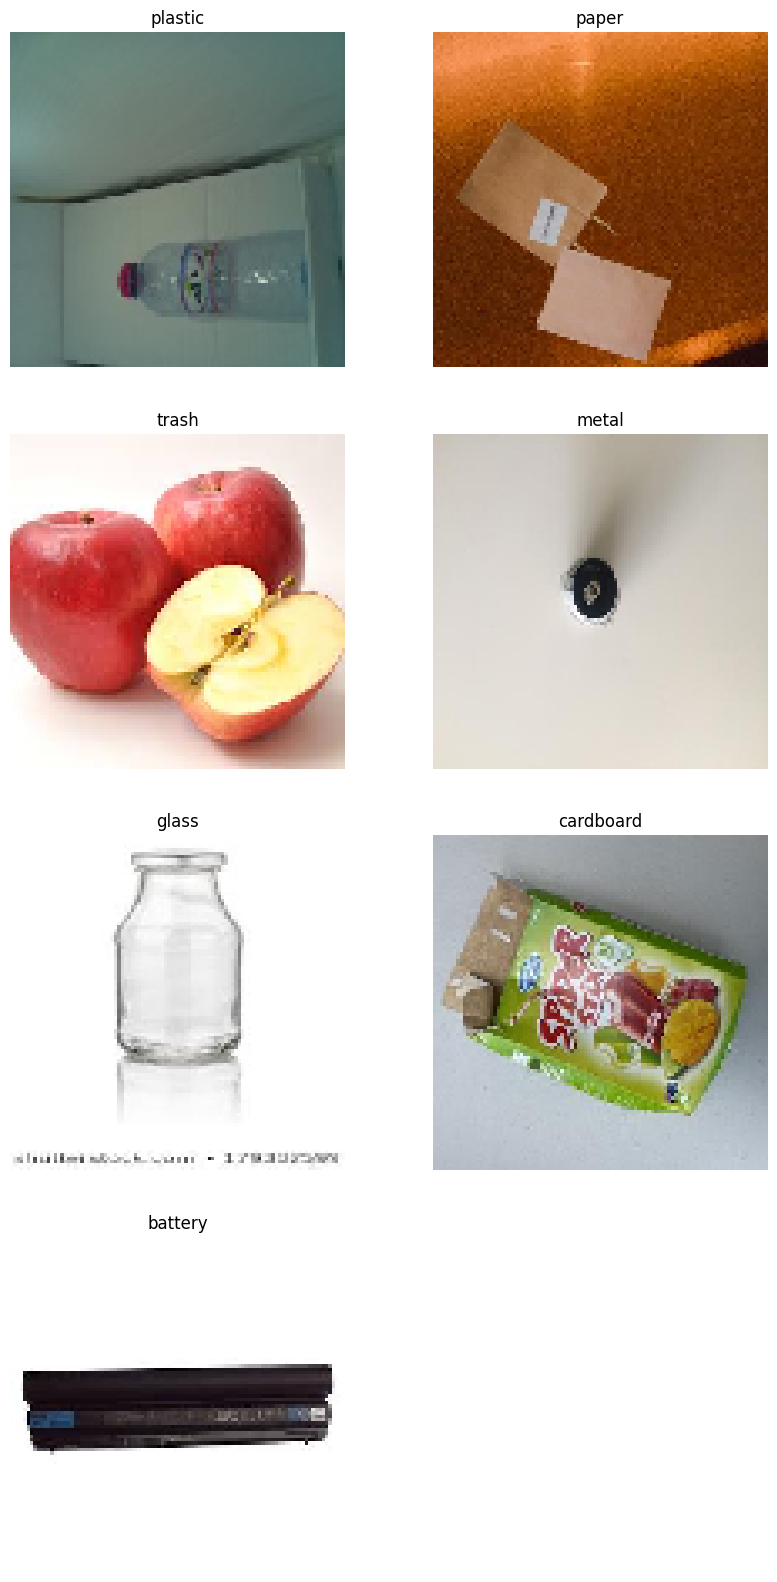

Total de imágenes: 20194
Número de imágenes por categoría:
plastic: 1789
paper: 5775
trash: 3412
metal: 2551
glass: 3275
cardboard: 2617
battery: 775


In [ ]:
# Cargamos el directorio
data_dir = '/content/Garbage classification'
# Obtenemos las categorias por el nombre de los folders
eurosat_categories = [
    cat for cat in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, cat))
]

# Visualizamos una imágen de cada categoría
plt.figure(figsize=(10, 20))
for i, category in enumerate(eurosat_categories):
    folder = os.path.join(data_dir, category)
    image_file = os.listdir(folder)[0]
    img_path = os.path.join(folder, image_file)
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(100, 100))
    plt.subplot(int(len(eurosat_categories)/2) + 1, 2, i+1)
    plt.title(category)
    plt.imshow(img)
    plt.axis('off')
plt.show()

image_count = {}
total_images = 0
for category in eurosat_categories:
    folder = os.path.join(data_dir, category)
    count = len(os.listdir(folder))
    image_count[category] = count
    total_images += count

# Cantidad de imágenes en las clases
print(f"Total de imágenes: {total_images}")
print("Número de imágenes por categoría:")
for category, count in image_count.items():
    print(f"{category}: {count}")

### **2. Preparación de los datos**

Este dataset no contiene un `.csv` con los labels de cada imagen, por lo tanto debemos crear el dataframe recorriendo los directorios de las imágenes.

In [ ]:
# Obtenemos las categorías desde las subcarpetas
categories = [
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d))
]

filepaths = []
labels = []

# Recorremos cada carpeta y recopilamos la información de las imágenes
for category in categories:
    cat_dir = os.path.join(data_dir, category)
    for root, _, files in os.walk(cat_dir):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp')):
                filepaths.append(os.path.join(root, f))
                labels.append(category)

# Creamos el dataframe con los labels de cada imagen
data_df = pd.DataFrame({
    'filepath': filepaths,
    'label': labels
})

print(data_df.head())

                                            filepath    label
0  /content/Garbage classification/plastic/022402...  plastic
1  /content/Garbage classification/plastic/021703...  plastic
2  /content/Garbage classification/plastic/plasti...  plastic
3  /content/Garbage classification/plastic/image2...  plastic
4  /content/Garbage classification/plastic/021809...  plastic


In [ ]:
# Dividimos entre entrenamiento, validacion y test
train_df, test_val_df = train_test_split(
    data_df,
    test_size=0.3,
    random_state=42,
    stratify=data_df['label']
)

val_df, test_df = train_test_split(
    test_val_df,
    test_size=1/3, # 1/3 del 30%, es decir el 10% del total
    random_state=42,
    stratify=test_val_df['label']
)

# Verificamos cantidad de imágenes para cada partición
print("Categorías:", categories)
print("Entrenamiento (70%):", len(train_df))
print("Validación (20%):", len(val_df))
print("Test (10%):", len(test_df))
print("Total de imágenes:", len(data_df))

Categorías encontradas: ['plastic', 'paper', 'trash', 'metal', 'glass', 'cardboard', 'battery']
Entrenamiento (70%): 14135
Validación (20%): 4039
Test (10%): 2020
Total de imágenes: 20194


In [ ]:
x_column = 'filepath'
y_column = 'label'

# Definimos los generadores pero usamos preprocess_input que viene de ResNetV2
train_datagen_resnet = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True
)

test_val_datagen_resnet = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Creamos los flow_from_dataframe con el size de 128x128
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_gen_res = train_datagen_resnet.flow_from_dataframe(
    dataframe=train_df,
    x_col=x_column,
    y_col=y_column,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen_res = test_val_datagen_resnet.flow_from_dataframe(
    dataframe=val_df,
    x_col=x_column,
    y_col=y_column,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen_res = test_val_datagen_resnet.flow_from_dataframe(
    dataframe=test_df,
    x_col=x_column,
    y_col=y_column,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 14135 validated image filenames belonging to 7 classes.
Found 4039 validated image filenames belonging to 7 classes.
Found 2020 validated image filenames belonging to 7 classes.


### **3. Modelamiento**

La arquitectura `ResNet50V2` consiste de 50 capas convolucionales donde entre las capas se usan las entradas anteriores como residual (`Residual Network`) para solucionar problemas de degradación de la información. La diferencia de esta versión 2 es la capacidad de procesamiento de imágenes, pues ya puede tener como input imágenes de 228x228 pixeles.

![ResNet50V2](https://github.com/nicolastibata/MINE_4210_ADL_202620/blob/main/docs/The-architecture-of-the-ResNet50-V2-model.png?raw=true)


Si quieres entender más a fondo la arquitectura puedes ver este video: https://youtu.be/woEs7UCaITo

In [ ]:
# Cargamos nuestro modelo preentrenado, congelando sus pesos
base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,  # Excluimos la capa final original de 1000 clases, aqui hacemos Transfer Learning con nuestra capa final
    input_shape=(128, 128, 3)
)
base_model.trainable = False  # Congelamos capas convolucionales, es decir no hacemos fine-tuning

# Construimos el clasificador para agregarlo como capa final
model_resnet = Sequential([
    base_model,
    GlobalAveragePooling2D(),  # Reduce dimensiones preservando características clave
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(train_gen_res.class_indices), activation='softmax')
])

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

# Definimos nuestros callbacks
callbacks_resnet = [
    ModelCheckpoint('best_resnet_model.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=8, verbose=1, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, verbose=1)
]

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 4, 4, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,827,975 (90.90 MB)

 Trainable params: 263,175 (1.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [ ]:
with tf.device('/device:GPU:0'):
    history_resnet = model_resnet.fit(
        train_gen_res,
        validation_data=val_gen_res,
        epochs=30,
        callbacks=callbacks_resnet
    )

Epoch 1/30
442/442 ━━━━━━━━━━━━━━━━━━━━ 113s 226ms/step - accuracy: 0.7698 - loss: 0.6960 - val_accuracy: 0.8519 - val_loss: 0.4594 - learning_rate: 0.0010
Epoch 2/30
442/442 ━━━━━━━━━━━━━━━━━━━━ 86s 194ms/step - accuracy: 0.8308 - loss: 0.5007 - val_accuracy: 0.8651 - val_loss: 0.4126 - learning_rate: 0.0010
Epoch 3/30
442/442 ━━━━━━━━━━━━━━━━━━━━ 87s 196ms/step - accuracy: 0.8562 - loss: 0.4162 - val_accuracy: 0.8727 - val_loss: 0.3839 - learning_rate: 0.0010
Epoch 4/30
442/442 ━━━━━━━━━━━━━━━━━━━━ 91s 206ms/step - accuracy: 0.8637 - loss: 0.3854 - val_accuracy: 0.8831 - val_loss: 0.3590 - learning_rate: 0.0010
Epoch 5/30
442/442 ━━━━━━━━━━━━━━━━━━━━ 88s 199ms/step - accuracy: 0.8745 - loss: 0.3651 - val_accuracy: 0.8834 - val_loss: 0.3554 - learning_rate: 0.0010
Epoch 6/30
442/442 ━━━━━━━━━━━━━━━━━━━━ 86s 195ms/step - accuracy: 0.8805 - loss: 0.3455 - val_accuracy: 0.8921 - val_loss: 0.3357 - learning_rate: 0.0010
Epoch 7/30
442/442 ━━━━━━━━━━━━━━━━━━━━ 86s 193ms/step - accuracy: 0.

**Veamos los resultados de nuestro modelo con los datos de entrenamiento**

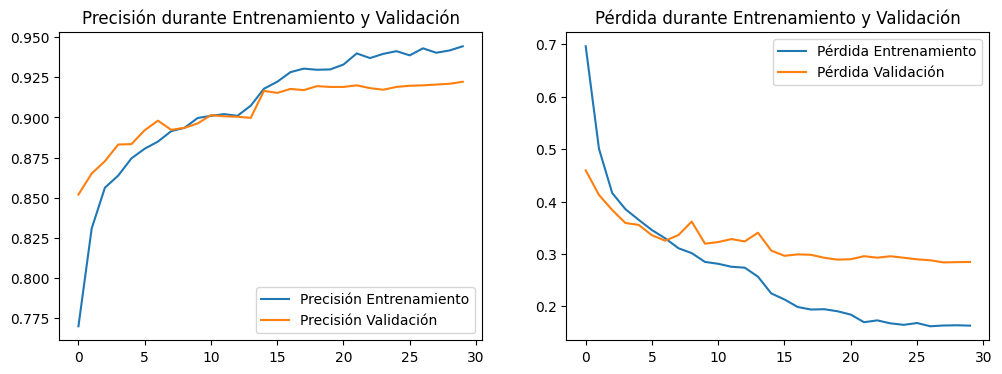

In [ ]:
# Visualización de la evolución del entrenamiento
acc = history_resnet.history['accuracy']
val_acc = history_resnet.history['val_accuracy']
loss = history_resnet.history['loss']
val_loss = history_resnet.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión Entrenamiento')
plt.plot(epochs_range, val_acc, label='Precisión Validación')
plt.legend(loc='lower right')
plt.title('Precisión durante Entrenamiento y Validación')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida Entrenamiento')
plt.plot(epochs_range, val_loss, label='Pérdida Validación')
plt.legend(loc='upper right')
plt.title('Pérdida durante Entrenamiento y Validación')
plt.show()

### **4. Evaluación**

64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step


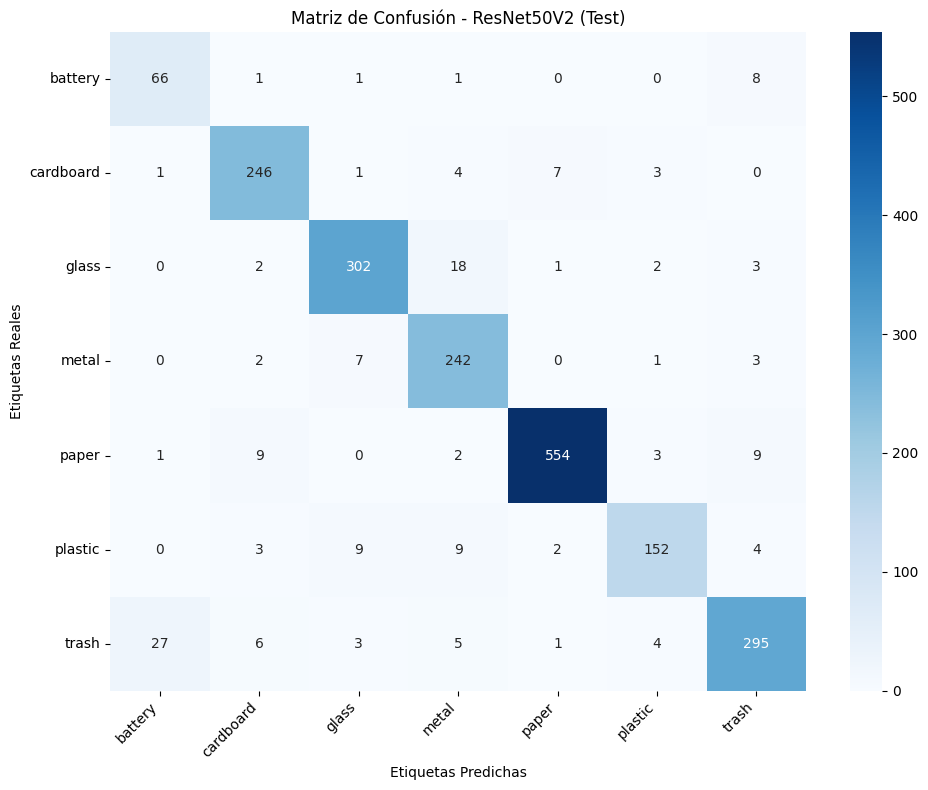

--- REPORTE DE CLASIFICACIÓN (RESNET50V2) ---
              precision    recall  f1-score   support

     battery       0.69      0.86      0.77        77
   cardboard       0.91      0.94      0.93       262
       glass       0.93      0.92      0.93       328
       metal       0.86      0.95      0.90       255
       paper       0.98      0.96      0.97       578
     plastic       0.92      0.85      0.88       179
       trash       0.92      0.87      0.89       341

    accuracy                           0.92      2020
   macro avg       0.89      0.91      0.90      2020
weighted avg       0.92      0.92      0.92      2020



In [ ]:
class_names = list(test_gen_res.class_indices.keys())

# 2. Generar predicciones en el conjunto de prueba con el modelo ResNet
test_gen_res.reset()
predicciones = model_resnet.predict(test_gen_res, verbose=1)
y_pred = np.argmax(predicciones, axis=1)
y_test = test_gen_res.classes

# 3. Graficar Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=plt.cm.Blues,
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Matriz de Confusión - ResNet50V2 (Test)')
plt.ylabel('Etiquetas Reales')
plt.xlabel('Etiquetas Predichas')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Generar el reporte de clasificación detallado
print("--- REPORTE DE CLASIFICACIÓN (RESNET50V2) ---")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

### **5. Preguntas**

1. ¿Cómo realizamos fine-tuning en este caso?
> Hint:
> ```python
> # Permitimos entrenamiento en la base
> base_model.trainable = True
> # Descongelamos las últimas 30 capas para entrenar
> fine_tune_at = len(base.model.layers) - 30
> for layer in base_model.layers[:fine_tune_at]:
>   layer.trainable = False
> ...
> ```


2. Realiza el entrenamiento con el modelo preentrenado `VGG16`. Qué diferencias encuentras en el entrenamiento y en la cantidad de hiperparámetros? [link](https://www.tensorflow.org/api_docs/python/tf/keras/applications/VGG16)